# 04 - LSTM Risk Forecasting

## Purpose
Train a sequence model for one-month-ahead signed environmental proxy-risk forecasting and compare it with notebook 03 baselines.

## Inputs
- `data/processed/processed_data.csv`
- Risk-scoring helpers from `src/risk_scoring.py`
- Optional baseline metrics from `reports/metrics.json`

## Outputs
- In-notebook sequence-model metrics and comparison table
- Optional `reports/lstm_test_predictions.csv`
- Optional `reports/lstm_holdout_predictions.csv`

## Notes
This notebook requires PyTorch and trains a real LSTM sequence model using the same rolling-window inputs as the other sequence notebooks. If PyTorch fails to import, the notebook attempts the local CPU repair helper and then raises clearly if LSTM cannot run. The learned score remains a proxy environmental anomaly index, not a calibrated flood or drought probability.


## 1. Configure LSTM Experiment
Defines project paths, sequence length, training settings, and deterministic random seed.

In [1]:

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.yaml"
SEQUENCE_LENGTH = 12
LSTM_HIDDEN_SIZE = 32
LSTM_NUM_LAYERS = 1
DROPOUT = 0.0
BATCH_SIZE = 32
MAX_EPOCHS = 80
PATIENCE = 10
LEARNING_RATE = 1e-3
RANDOM_STATE = 42
RUN_LSTM_TRAINING = True
AUTO_REPAIR_PYTORCH = True


## 2. Load Scored Forecasting Table
Recreates the same training-only anomaly scoring and one-month-ahead target table used by notebook 03.

In [2]:

import json
import random
import subprocess

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
except Exception as exc:
    if not AUTO_REPAIR_PYTORCH:
        raise RuntimeError("PyTorch import failed. Run scripts/repair_pytorch_cpu.py before notebook 04.") from exc
    print(f"PyTorch import failed before repair: {type(exc).__name__}: {exc}")
    subprocess.check_call([sys.executable, str(PROJECT_ROOT / "scripts" / "repair_pytorch_cpu.py")])
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset

from src.risk_scoring import (
    metrics_frame,
    prepare_scored_forecasting_table,
    regression_metrics,
    select_forecasting_feature_columns,
)

print("torch", torch.__version__)
print("cuda_available", torch.cuda.is_available())

config, scored, forecasting_table, splits, artifacts = prepare_scored_forecasting_table(CONFIG_PATH)
print("forecasting_table", forecasting_table.shape)
print({name: int(mask.sum()) for name, mask in splits.items()})
forecasting_table.head()


torch 2.12.1+cpu
cuda_available False
forecasting_table (3234, 189)
{'train': 2548, 'test': 588, 'holdout': 49}


,sample_id,grid_row,grid_col,latitude,longitude,month,ndvi_mean,evi_mean,ndmi_mean,ndwi_mean,...,flood_direction_score,drought_direction_score,risk_direction,signed_risk_score,risk_severity,target_month,target_risk_score_t_plus_1,target_anomaly_magnitude_t_plus_1,target_risk_direction_t_plus_1,target_available_flag
0,sagil_1,0,0,2.341985,102.629998,2021-01-01,0.559763,0.445020,0.106943,-0.527780,...,0.445832,0.599206,drought,-0.101339,low,2021-02-01,-0.407264,0.407264,drought,1
1,sagil_1,0,0,2.341985,102.629998,2021-02-01,0.455169,0.350538,0.100939,-0.444946,...,0.014415,2.442392,drought,-0.407264,high,2021-03-01,-0.198326,0.198326,drought,1
2,sagil_1,0,0,2.341985,102.629998,2021-03-01,0.419253,0.367311,0.051128,-0.422619,...,0.278319,1.229426,drought,-0.198326,moderate,2021-04-01,0.097555,0.097555,flood,1
3,sagil_1,0,0,2.341985,102.629998,2021-04-01,0.669163,0.591764,0.192576,-0.590714,...,0.229811,0.103790,flood,0.097555,low,2021-05-01,0.153601,0.153601,flood,1
4,sagil_1,0,0,2.341985,102.629998,2021-05-01,0.719184,0.647537,0.246818,-0.618140,...,0.817367,0.000000,flood,0.153601,low,2021-06-01,0.047559,0.047559,flood,1


## 3. Prepare Sequence Dataset
Builds rolling monthly sequences within each `sample_id`. Each training example uses the previous `SEQUENCE_LENGTH` source months to predict the next-month signed risk score for the final source month in the sequence.

In [3]:
train_rows = forecasting_table.loc[splits["train"]].copy()
feature_columns = [
    column for column in select_forecasting_feature_columns(forecasting_table)
    if column in train_rows.columns and train_rows[column].notna().any()
]

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
imputer.fit(train_rows[feature_columns])
scaler.fit(imputer.transform(train_rows[feature_columns]))

model_table = forecasting_table.sort_values(["sample_id", "month"]).reset_index(drop=True).copy()
model_table[feature_columns] = scaler.transform(imputer.transform(model_table[feature_columns]))

def build_sequences(table, split_mask, sequence_length, feature_columns):
    selected_indices = set(table.index[split_mask])
    x_values = []
    y_values = []
    metadata_rows = []
    for sample_id, sample_data in table.groupby("sample_id", sort=False):
        sample_data = sample_data.sort_values("month")
        sample_indices = list(sample_data.index)
        for position, row_index in enumerate(sample_indices):
            if row_index not in selected_indices:
                continue
            start = position - sequence_length + 1
            if start < 0:
                continue
            window_indices = sample_indices[start:position + 1]
            window = table.loc[window_indices, feature_columns]
            if window.isna().any().any():
                continue
            x_values.append(window.to_numpy(dtype=np.float32))
            y_values.append(float(table.loc[row_index, "target_risk_score_t_plus_1"]))
            metadata_rows.append(table.loc[row_index, ["sample_id", "month", "target_month", "target_risk_score_t_plus_1", "risk_direction", "risk_severity"]])
    x_array = np.asarray(x_values, dtype=np.float32)
    y_array = np.asarray(y_values, dtype=np.float32).reshape(-1, 1)
    metadata = pd.DataFrame(metadata_rows).reset_index(drop=True) if metadata_rows else pd.DataFrame()
    return x_array, y_array, metadata

x_train, y_train, train_meta = build_sequences(model_table, splits["train"], SEQUENCE_LENGTH, feature_columns)
x_test, y_test, test_meta = build_sequences(model_table, splits["test"], SEQUENCE_LENGTH, feature_columns)
x_holdout, y_holdout, holdout_meta = build_sequences(model_table, splits["holdout"], SEQUENCE_LENGTH, feature_columns)

print("features", len(feature_columns))
print("train", x_train.shape, y_train.shape)
print("test", x_test.shape, y_test.shape)
print("holdout", x_holdout.shape, y_holdout.shape)

features 176
train (2009, 12, 176) (2009, 1)
test (588, 12, 176) (588, 1)
holdout (49, 12, 176) (49, 1)


## 4. Define Real LSTM Model
Imports PyTorch as a required dependency and defines the compact LSTM regressor. There is no alternate scikit-learn sequence path in this notebook.


In [4]:

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

if x_train.size == 0 or x_test.size == 0:
    raise ValueError(
        "Not enough sequence rows for notebook 04. Reduce SEQUENCE_LENGTH or confirm processed_data.csv has enough months."
    )

sequence_model_name = "lstm"


class LSTMRiskRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, x):
        output, _ = self.lstm(x)
        return self.head(output[:, -1, :])


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMRiskRegressor(
    input_size=x_train.shape[-1],
    hidden_size=LSTM_HIDDEN_SIZE,
    num_layers=LSTM_NUM_LAYERS,
    dropout=DROPOUT,
).to(device)
print(model)
print("device", device)


LSTMRiskRegressor(
  (lstm): LSTM(176, 32, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)
device cpu


## 5. Train Real LSTM Model
Uses the tail of the chronological training sequences as validation for early stopping. The test and holdout periods are not used for training or early stopping.


In [5]:

def train_lstm(model, x_train, y_train):
    split_index = max(1, int(len(x_train) * 0.85))
    if split_index >= len(x_train):
        split_index = len(x_train) - 1
    train_dataset = TensorDataset(
        torch.tensor(x_train[:split_index], dtype=torch.float32),
        torch.tensor(y_train[:split_index], dtype=torch.float32),
    )
    valid_dataset = TensorDataset(
        torch.tensor(x_train[split_index:], dtype=torch.float32),
        torch.tensor(y_train[split_index:], dtype=torch.float32),
    )
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.MSELoss()
    best_state = None
    best_valid_loss = float("inf")
    wait = 0
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_losses = []
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            prediction = model(x_batch)
            loss = loss_fn(prediction, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(float(loss.detach().cpu()))

        model.eval()
        valid_losses = []
        with torch.no_grad():
            for x_batch, y_batch in valid_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                valid_losses.append(float(loss_fn(model(x_batch), y_batch).detach().cpu()))
        train_loss = float(np.mean(train_losses)) if train_losses else float("nan")
        valid_loss = float(np.mean(valid_losses)) if valid_losses else train_loss
        history.append({"epoch": epoch, "train_loss": train_loss, "valid_loss": valid_loss})

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to("cpu")
    return pd.DataFrame(history)


if RUN_LSTM_TRAINING:
    history = train_lstm(model, x_train, y_train)
    display(history.tail())
else:
    history = pd.DataFrame()
    print("RUN_LSTM_TRAINING is False.")


,epoch,train_loss,valid_loss
13,14,0.022369,0.046054
14,15,0.019518,0.049983
15,16,0.019216,0.048042
16,17,0.016199,0.050416
17,18,0.013273,0.055247


## 6. Evaluate and Save LSTM Model
Scores the real PyTorch LSTM on the chronological test period, writes prediction files, and saves LSTM artifacts for demo inference.


In [6]:

def predict_lstm(model, x_array):
    if len(x_array) == 0:
        return np.array([])
    model.eval()
    predictions = []
    loader = DataLoader(torch.tensor(x_array, dtype=torch.float32), batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for x_batch in loader:
            predictions.append(model(x_batch).detach().cpu().numpy().reshape(-1))
    return np.concatenate(predictions)


def save_lstm_artifacts():
    import joblib

    artifacts_dir = PROJECT_ROOT / config["paths"]["artifacts_dir"]
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(imputer, artifacts_dir / "sequence_feature_imputer.joblib")
    joblib.dump(scaler, artifacts_dir / "sequence_feature_scaler.joblib")
    torch.save(model.state_dict(), artifacts_dir / "lstm_model.pt")

    metadata = {
        "model": "lstm",
        "sequence_length": SEQUENCE_LENGTH,
        "feature_columns": feature_columns,
        "input_size": int(x_train.shape[-1]),
        "hidden_size": LSTM_HIDDEN_SIZE,
        "num_layers": LSTM_NUM_LAYERS,
        "dropout": DROPOUT,
        "model_artifact": "lstm_model.pt",
        "imputer_artifact": "sequence_feature_imputer.joblib",
        "scaler_artifact": "sequence_feature_scaler.joblib",
    }
    (artifacts_dir / "sequence_model_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")


y_test_pred = predict_lstm(model, x_test)
y_holdout_pred = predict_lstm(model, x_holdout)
lstm_metrics = {"lstm": regression_metrics(y_test.reshape(-1), y_test_pred)}
print(lstm_metrics)

reports_dir = PROJECT_ROOT / config["paths"]["reports_dir"]
reports_dir.mkdir(parents=True, exist_ok=True)
save_lstm_artifacts()

lstm_test_predictions = test_meta.rename(columns={"target_risk_score_t_plus_1": "actual_proxy_score"}).copy()
lstm_test_predictions["predicted_proxy_score"] = y_test_pred
lstm_test_predictions["model"] = "lstm"
lstm_test_predictions["split"] = "test"
lstm_test_predictions.to_csv(reports_dir / "lstm_test_predictions.csv", index=False)

lstm_holdout_predictions = pd.DataFrame()
if len(holdout_meta):
    lstm_holdout_predictions = holdout_meta.rename(columns={"target_risk_score_t_plus_1": "actual_proxy_score"}).copy()
    lstm_holdout_predictions["predicted_proxy_score"] = y_holdout_pred
    lstm_holdout_predictions["model"] = "lstm"
    lstm_holdout_predictions["split"] = "holdout"
    lstm_holdout_predictions.to_csv(reports_dir / "lstm_holdout_predictions.csv", index=False)

display(lstm_test_predictions.head())


{'lstm': {'mae': 0.21904109697788954, 'median_ae': 0.17632205039262772, 'rmse': 0.3018645659179016, 'r2': -0.27677621332725044, 'bias': 0.08709271579702087, 'direction_accuracy': 0.5884353741496599}}


,sample_id,month,target_month,actual_proxy_score,risk_direction,risk_severity,predicted_proxy_score,model,split
0,sagil_1,2025-05-01,2025-06-01,-0.206594,drought,low,-0.019166,lstm,test
1,sagil_1,2025-06-01,2025-07-01,-0.324576,drought,moderate,0.025557,lstm,test
2,sagil_1,2025-07-01,2025-08-01,-0.091162,drought,high,0.006145,lstm,test
3,sagil_1,2025-08-01,2025-09-01,-0.069916,drought,low,0.193056,lstm,test
4,sagil_1,2025-09-01,2025-10-01,-0.156710,drought,low,0.118420,lstm,test


## 7. Final Comparison
Compares the LSTM model against the notebook 03 baselines. Use RMSE as the primary ranking metric and check direction accuracy for flood/drought sign behavior.


In [7]:

metrics_path = reports_dir / "metrics.json"
if metrics_path.exists():
    baseline_metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
else:
    baseline_metrics = {}
    print("Baseline metrics not found. Run notebook 03 first for persistence, Ridge, and Random Forest comparison.")

comparison_metrics = {**baseline_metrics, **lstm_metrics}
comparison = metrics_frame(comparison_metrics)
comparison.to_csv(reports_dir / "model_comparison_with_lstm.csv", index=False)
display(comparison)

if not comparison.empty:
    best = comparison.iloc[0]
    print(f"Best model by RMSE: {best['model']} (RMSE={best['rmse']:.6f}, MAE={best['mae']:.6f}, R2={best['r2']:.4f})")

    if best["model"] == "lstm":
        lstm_test_predictions.to_csv(reports_dir / "test_predictions.csv", index=False)
        if not lstm_holdout_predictions.empty:
            lstm_holdout_predictions.to_csv(reports_dir / "holdout_predictions.csv", index=False)

        artifacts_dir = PROJECT_ROOT / config["paths"]["artifacts_dir"]
        registry_path = artifacts_dir / "model_registry.json"
        if registry_path.exists():
            registry = json.loads(registry_path.read_text(encoding="utf-8"))
        else:
            registry = {"artifacts": {}}
        registry["best_model"] = "lstm"
        registry.setdefault("optional_sequence_models", [])
        if "lstm" not in registry["optional_sequence_models"]:
            registry["optional_sequence_models"].append("lstm")
        registry.setdefault("artifacts", {}).update({
            "lstm_model": "artifacts/lstm_model.pt",
            "sequence_feature_imputer": "artifacts/sequence_feature_imputer.joblib",
            "sequence_feature_scaler": "artifacts/sequence_feature_scaler.joblib",
            "sequence_model_metadata": "artifacts/sequence_model_metadata.json",
        })
        registry_path.write_text(json.dumps(registry, indent=2), encoding="utf-8")
        print("LSTM is the new best test-RMSE model. Generic prediction reports were updated.")


,model,mae,median_ae,rmse,r2,bias,direction_accuracy
3,lstm,0.219041,0.176322,0.301865,-0.276776,0.087093,0.588435
0,persistence,0.238438,0.210891,0.330282,-0.528484,-0.014090,0.687075
2,random_forest,0.246934,0.180941,0.345648,-0.674011,0.164102,0.663265
1,ridge,0.280952,0.232747,0.360969,-0.825706,0.064840,0.607143


Best model by RMSE: lstm (RMSE=0.301865, MAE=0.219041, R2=-0.2768)
LSTM is the new best test-RMSE model. Generic prediction reports were updated.


## 8. LSTM Visualizations
Plots LSTM training history, final comparison metrics, test predictions, residuals, and holdout predictions.


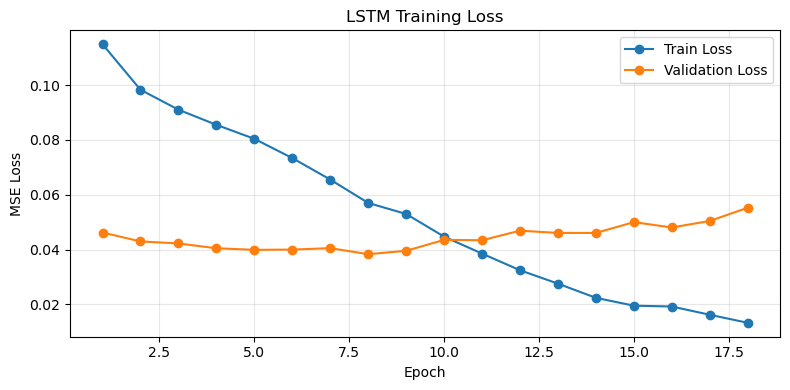

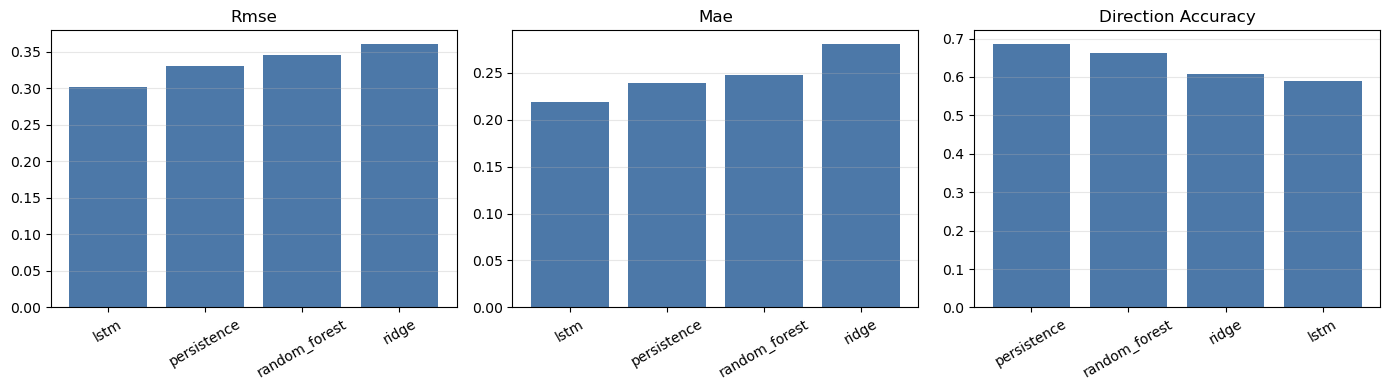

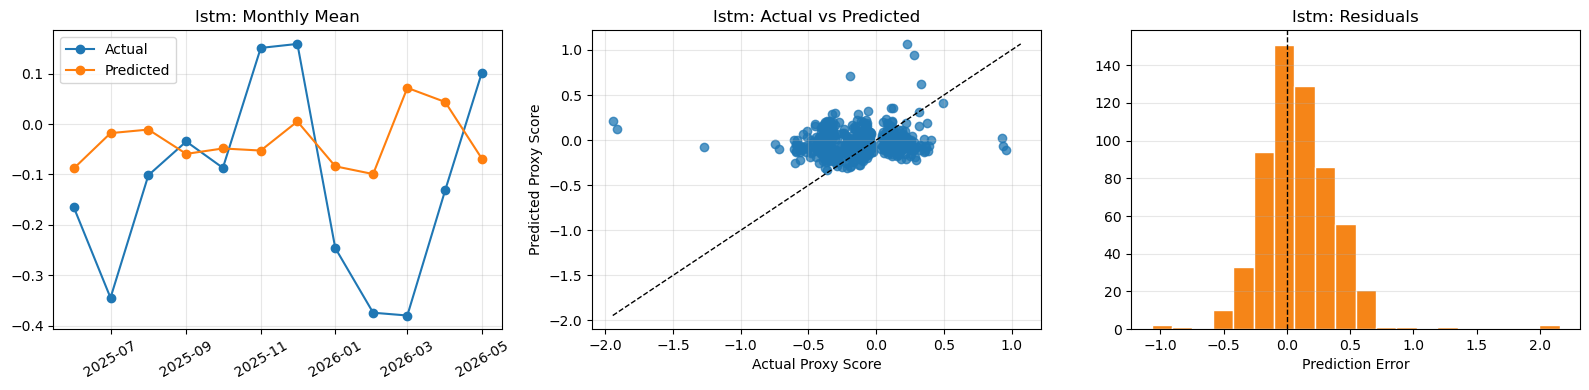

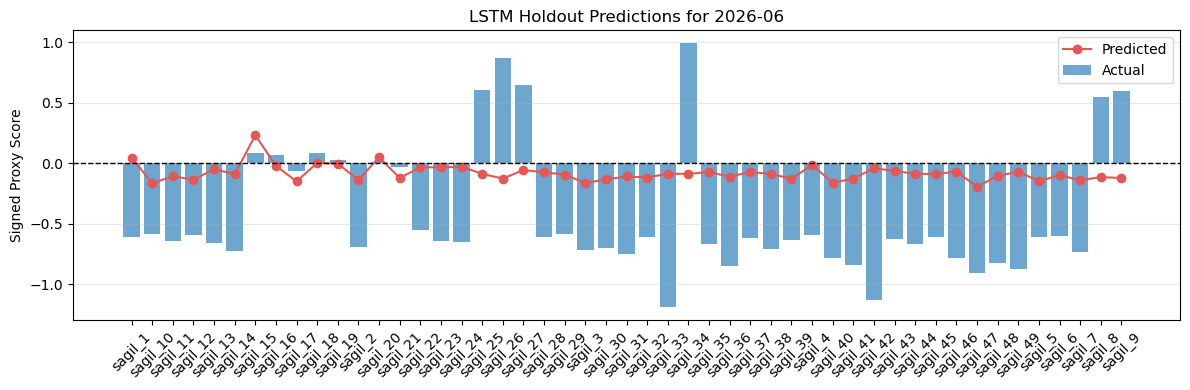

In [8]:

import matplotlib.pyplot as plt


def plot_sequence_training_history(history):
    if history.empty:
        print("No LSTM training history available for plotting.")
        return
    fig, axis = plt.subplots(figsize=(8, 4))
    axis.plot(history["epoch"], history["train_loss"], marker="o", label="Train Loss")
    axis.plot(history["epoch"], history["valid_loss"], marker="o", label="Validation Loss")
    axis.set_title("LSTM Training Loss")
    axis.set_xlabel("Epoch")
    axis.set_ylabel("MSE Loss")
    axis.legend()
    axis.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_sequence_metric_comparison(comparison):
    if comparison.empty:
        print("No comparison table available for plotting.")
        return
    metrics_to_plot = ["rmse", "mae", "direction_accuracy"]
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 4))
    for axis, metric in zip(axes, metrics_to_plot):
        sorted_table = comparison.sort_values(metric, ascending=(metric != "direction_accuracy"))
        axis.bar(sorted_table["model"], sorted_table[metric], color="#4C78A8")
        axis.set_title(metric.replace("_", " ").title())
        axis.tick_params(axis="x", rotation=30)
        axis.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_sequence_predictions(predictions, title_prefix):
    if predictions.empty:
        print(f"No sequence predictions available for {title_prefix}.")
        return
    working = predictions.copy()
    working["target_month"] = pd.to_datetime(working["target_month"])
    working["error"] = working["predicted_proxy_score"] - working["actual_proxy_score"]
    working = working.sort_values(["target_month", "sample_id"])
    monthly = working.groupby("target_month", as_index=False)[["actual_proxy_score", "predicted_proxy_score"]].mean()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(monthly["target_month"], monthly["actual_proxy_score"], marker="o", label="Actual")
    axes[0].plot(monthly["target_month"], monthly["predicted_proxy_score"], marker="o", label="Predicted")
    axes[0].set_title(f"{title_prefix}: Monthly Mean")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].scatter(working["actual_proxy_score"], working["predicted_proxy_score"], alpha=0.75)
    lower = min(working["actual_proxy_score"].min(), working["predicted_proxy_score"].min())
    upper = max(working["actual_proxy_score"].max(), working["predicted_proxy_score"].max())
    axes[1].plot([lower, upper], [lower, upper], linestyle="--", color="black", linewidth=1)
    axes[1].set_title(f"{title_prefix}: Actual vs Predicted")
    axes[1].set_xlabel("Actual Proxy Score")
    axes[1].set_ylabel("Predicted Proxy Score")
    axes[1].grid(alpha=0.3)

    axes[2].hist(working["error"], bins=20, color="#F58518", edgecolor="white")
    axes[2].axvline(0, linestyle="--", color="black", linewidth=1)
    axes[2].set_title(f"{title_prefix}: Residuals")
    axes[2].set_xlabel("Prediction Error")
    axes[2].grid(axis="y", alpha=0.3)

    fig.tight_layout()
    plt.show()


def plot_sequence_holdout(holdout_path):
    if not holdout_path.exists():
        print("No LSTM holdout report found for plotting.")
        return
    holdout = pd.read_csv(holdout_path)
    if holdout.empty:
        print("LSTM holdout report is empty.")
        return
    x_labels = holdout["sample_id"].astype(str)
    fig, axis = plt.subplots(figsize=(12, 4))
    axis.bar(x_labels, holdout["actual_proxy_score"], alpha=0.65, label="Actual")
    axis.plot(x_labels, holdout["predicted_proxy_score"], marker="o", color="#E45756", label="Predicted")
    axis.axhline(0, linestyle="--", color="black", linewidth=1)
    axis.set_title("LSTM Holdout Predictions for 2026-06")
    axis.set_ylabel("Signed Proxy Score")
    axis.tick_params(axis="x", rotation=45)
    axis.legend()
    axis.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


plot_sequence_training_history(history)
plot_sequence_metric_comparison(comparison)
plot_sequence_predictions(lstm_test_predictions, "lstm")
plot_sequence_holdout(reports_dir / "lstm_holdout_predictions.csv")
